# Jean pockets

Are women jean pockets ridiculously small? Let's look at the data!

The file `jean-pocket-measurements.csv` shows pocket measurements for 20 popular brands.
Four pairs of jeans from each brand were measured: men's and women's skinny and straight styles. All jeans were designated a 32-inch waistband. 

The following measurements are included:
- `height_front`: maximum front pocket height (cm)
- `height_back`: maximum back pocket height (cm)
- `width_front`: maximum front pocket width (cm)
- `width_back`: maximum back pocket width (cm)

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'jean-pocket-measurements.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
df = pd.read_csv('jean-pocket-measurements.csv')
df.head()

,brand,style,gender,height_front,width_front,height_back,width_back
0,3fe5003e,skinny,women,14.5,16.5,15.0,13.7
1,3fe5003e,straight,women,14.5,16.0,15.5,13.0
2,790c6eab,skinny,women,13.0,14.5,15.5,13.5
3,790c6eab,straight,women,13.0,14.5,14.5,13.0
4,26aaf627,skinny,women,13.0,14.0,14.0,14.2


### Project Ideas

- What is the average difference in pocket `height_front` between women's and men's jeans?

- Is there a significant difference in pocket `height_front` between skinny and straight styles within the same gender?

- How do back pocket sizes compare between women's and men's jeans?

- Measure your phone's height. What percentage of women's and men's jeans can comfortably fit your phone in the pockets?



In [4]:
# YOUR CODE HERE (add more cells as needed)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         80 non-null     str    
 1   style         80 non-null     str    
 2   gender        80 non-null     str    
 3   height_front  80 non-null     float64
 4   width_front   80 non-null     float64
 5   height_back   80 non-null     float64
 6   width_back    80 non-null     float64
dtypes: float64(4), str(3)
memory usage: 4.5 KB


In [6]:
df.sample(10)

,brand,style,gender,height_front,width_front,height_back,width_back
33,57ed7595,straight,women,16.0,13.5,15.0,13.0
20,1428e336,skinny,women,12.5,16.0,14.0,13.0
59,2abe57bc,straight,men,22.5,14.5,15.5,13.5
61,ce93e0bd,straight,men,24.5,17.0,14.0,12.0
44,ba56feb3,skinny,men,22.0,15.0,16.5,14.2
38,3fe5003e,skinny,men,26.0,17.0,17.0,14.0
24,dfc9a4ab,straight,women,14.5,14.0,16.0,13.0
55,9cc5821d,straight,men,21.5,16.5,16.0,14.0
53,7398d4c6,straight,men,22.5,17.0,16.2,13.0
13,7b34fdbd,straight,women,13.5,17.0,15.0,14.5


In [7]:
df.shape

(80, 7)

In [8]:
df.isnull().sum()

brand           0
style           0
gender          0
height_front    0
width_front     0
height_back     0
width_back      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [22]:
avg_by_gender = df.groupby('gender')['height_front'].mean()
diff = avg_by_gender['women'] - avg_by_gender['men']
print(f"Average height difference (women - men): {diff:.2f}")

Average height difference (women - men): -8.80


In [25]:
style = df.groupby('style')['height_front'].mean()
diff_style = style['skinny'] - style['straight']
print(f"Average height difference (skinny - straight): {diff_style:.2f}")

Average height difference (skinny - straight): -0.00


In [ ]:
# by ai
from scipy import stats

for gender in ["women", "men"]:
    group = df[df["gender"] == gender]
    skinny = group[group["style"] == "skinny"]["height_front"]
    straight = group[group["style"] == "straight"]["height_front"]
    
    print(f"\n--- {gender.upper()} ---")
    print(f"  Skinny  avg: {skinny.mean():.2f}  (n={len(skinny)})")
    print(f"  Straight avg: {straight.mean():.2f}  (n={len(straight)})")
    
    if len(skinny) > 1 and len(straight) > 1:
        t_stat, p_val = stats.ttest_ind(skinny, straight)
        print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
        print(f"  {'Significant difference!' if p_val < 0.05 else 'No significant difference.'}")
    else:
        print("  Not enough data for a t-test.")


--- WOMEN ---
  Skinny  avg: 14.27  (n=20)
  Straight avg: 14.38  (n=20)
  t-statistic: -0.171, p-value: 0.865
  No significant difference.

--- MEN ---
  Skinny  avg: 23.18  (n=20)
  Straight avg: 23.07  (n=20)
  t-statistic: 0.167, p-value: 0.868
  No significant difference.


In [36]:
back_stats = df.groupby("gender")[["height_back", "width_back"]].agg(["mean", "std"])
print(back_stats)

# Also compute back pocket area
df["back_area"] = df["height_back"] * df["width_back"]
print("\nAverage back pocket area by gender:")
print(df.groupby("gender")["back_area"].mean())

       height_back           width_back          
              mean       std       mean       std
gender                                           
men        16.0075  0.835245    13.7025  0.881865
women      15.1225  0.789835    13.3400  0.818003

Average back pocket area by gender:
gender
men      219.70875
women    201.82125
Name: back_area, dtype: float64


In [34]:
phone_height = float(input("Enter your phone's height (in same units as data, e.g. cm): "))

# A pocket "comfortably fits" if height_front > phone_height
df["fits_phone"] = df["height_front"] > phone_height

result = df.groupby("gender")["fits_phone"].mean() * 100
print(f"\nPercentage of jeans that fit your phone (height > {phone_height}):")
print(result.round(1))


Percentage of jeans that fit your phone (height > 6.0):
gender
men      100.0
women    100.0
Name: fits_phone, dtype: float64


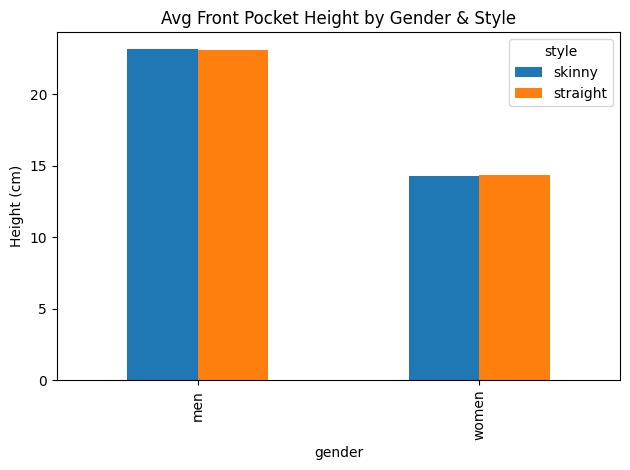

In [35]:
import matplotlib.pyplot as plt

df.groupby(["gender", "style"])["height_front"].mean().unstack().plot(kind="bar")
plt.title("Avg Front Pocket Height by Gender & Style")
plt.ylabel("Height (cm)")
plt.tight_layout()
plt.show()